# 01 · Linear regression: `src/regression/_linear.py`

Tests for `LinearRegression` (Ridge, closed form), `SGDRegression`, `StandardScaler`, the R² `score`, and the validation helpers.

| Data | Source | What it tests |
|---|---|---|
| Synthetic `y = Xw + b + noise` | generated | the true coefficients are recovered exactly |
| Diabetes (442 × 10) | scikit-learn, bundled | same answer as scikit-learn's `Ridge`, the regularisation path, SGD convergence |
| California Housing (20 640 × 8) | **online** (`fetch_california_housing`) | real-world performance on a large dataset |

scikit-learn is used **only** to load data and as a reference implementation to compare against.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model, preprocessing, metrics
from sklearn.model_selection import train_test_split

from _testkit import SEED, Checks, load_online, timed
from src.regression._linear import (
    LinearRegression, SGDRegression, StandardScaler,
    check_array, check_X_y, check_is_fitted,
)

checks = Checks("01 linear regression")
rng = np.random.default_rng(SEED)

## 1. Recovering known coefficients

With `alpha = 0`, Ridge reduces to ordinary least squares. On data generated from known weights with little noise, the fitted `coef_` and `intercept_` should match the true values.

In [2]:
true_w = np.array([3.0, -2.0, 0.5, 0.0, 1.5])
true_b = 4.0
X_syn = rng.normal(size=(1000, 5))
y_syn = X_syn @ true_w + true_b + rng.normal(scale=0.05, size=1000)

ols = LinearRegression(alpha=0.0).fit(X_syn, y_syn)
print("true coef:", true_w, "| fitted:", ols.coef_.round(3))
print("true intercept:", true_b, "| fitted:", round(ols.intercept_, 3))

checks.close("OLS recovers the true coefficients", ols.coef_, true_w, atol=0.01)
checks.close("OLS recovers the true intercept", ols.intercept_, true_b, atol=0.01)
checks.at_least("OLS R² on noise-free-ish data", ols.score(X_syn, y_syn), 0.999)

true coef: [ 3.  -2.   0.5  0.   1.5] | fitted: [ 2.998 -2.001  0.499 -0.     1.499]
true intercept: 4.0 | fitted: 4.002
✅ OLS recovers the true coefficients  (max |Δ| = 2.31e-03)
✅ OLS recovers the true intercept  (max |Δ| = 2.32e-03)
✅ OLS R² on noise-free-ish data  (0.9998 ≥ 0.999)


True

## 2. Ridge matches scikit-learn exactly

Both implementations minimise `‖y − Xw − b‖² + α‖w‖²` and leave the intercept unpenalised, so their solutions should agree to numerical precision.

In [3]:
X_dia, y_dia = datasets.load_diabetes(return_X_y=True)

for alpha in [0.0, 0.1, 1.0, 10.0]:
    ours = LinearRegression(alpha=alpha).fit(X_dia, y_dia)
    ref = linear_model.Ridge(alpha=alpha).fit(X_dia, y_dia)
    checks.close(f"Ridge α={alpha}: coef_ == sklearn", ours.coef_, ref.coef_, rtol=1e-6, atol=1e-6)
    checks.close(f"Ridge α={alpha}: intercept_ == sklearn", ours.intercept_, ref.intercept_, rtol=1e-6, atol=1e-6)

✅ Ridge α=0.0: coef_ == sklearn  (max |Δ| = 1.77e-11)
✅ Ridge α=0.0: intercept_ == sklearn  (max |Δ| = 2.84e-14)
✅ Ridge α=0.1: coef_ == sklearn  (max |Δ| = 3.69e-12)
✅ Ridge α=0.1: intercept_ == sklearn  (max |Δ| = 8.53e-14)
✅ Ridge α=1.0: coef_ == sklearn  (max |Δ| = 5.68e-13)
✅ Ridge α=1.0: intercept_ == sklearn  (max |Δ| = 5.68e-14)
✅ Ridge α=10.0: coef_ == sklearn  (max |Δ| = 9.95e-14)
✅ Ridge α=10.0: intercept_ == sklearn  (max |Δ| = 0.00e+00)


### Regularisation path

As `α` grows, the penalty shrinks every coefficient toward zero, so the coefficient norm must decrease monotonically.

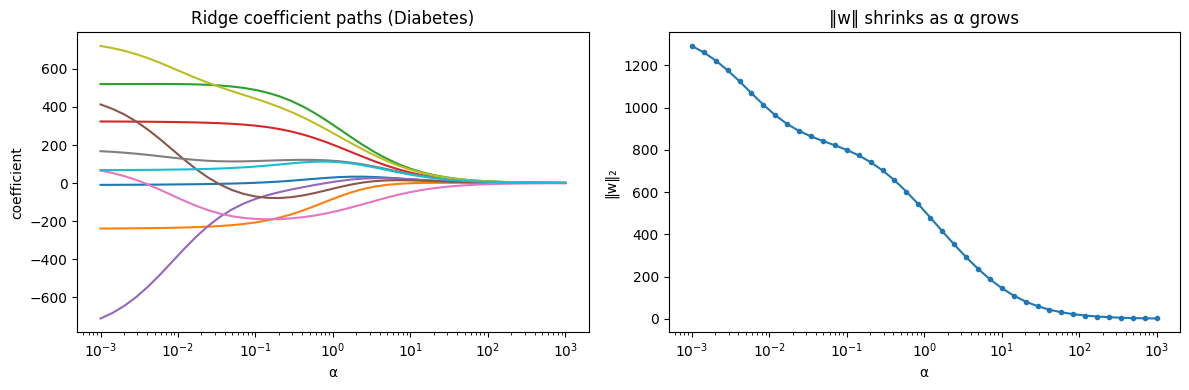

✅ coefficient norm decreases monotonically with α


True

In [4]:
alphas = np.logspace(-3, 3, 40)
coefs = np.array([LinearRegression(alpha=a).fit(X_dia, y_dia).coef_ for a in alphas])
norms = np.linalg.norm(coefs, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogx(alphas, coefs)
ax[0].set(title="Ridge coefficient paths (Diabetes)", xlabel="α", ylabel="coefficient")
ax[1].semilogx(alphas, norms, marker=".")
ax[1].set(title="‖w‖ shrinks as α grows", xlabel="α", ylabel="‖w‖₂")
plt.tight_layout(); plt.show()

checks.check("coefficient norm decreases monotonically with α", np.all(np.diff(norms) <= 1e-9))

## 3. `StandardScaler` and the R² score

The scaler computes `(x − μ) / (σ + ε)` with `ε = 1e-7`. The `ε` guards against constant features, so results match scikit-learn to a relative tolerance of about `1e-5` rather than exactly. `score` should equal `sklearn.metrics.r2_score`.

In [5]:
ours = StandardScaler().fit(X_dia)
ref = preprocessing.StandardScaler().fit(X_dia)
checks.close("StandardScaler.transform ≈ sklearn (ε = 1e-7)", ours.transform(X_dia), ref.transform(X_dia), rtol=1e-4, atol=1e-6)
checks.close("fit_transform == fit().transform()", StandardScaler().fit_transform(X_dia), ours.transform(X_dia))

Z = StandardScaler().fit_transform(X_dia)
checks.close("scaled features have mean 0", Z.mean(axis=0), np.zeros(Z.shape[1]), atol=1e-12)
checks.close("scaled features have std ≈ 1", Z.std(axis=0), np.ones(Z.shape[1]), atol=1e-5)

X_const = np.column_stack([X_dia[:, 0], np.full(len(X_dia), 7.0)])
checks.check("constant feature does not produce NaN", np.isfinite(StandardScaler().fit_transform(X_const)).all())

# Known bug: with_mean=False / with_std=False leave mean_ / std_ = None after fit(),
# so transform() trips check_is_fitted and raises "not fitted".
checks.known_bug("StandardScaler(with_mean=False) can transform",
                 lambda: np.allclose(StandardScaler(with_mean=False).fit_transform(X_dia),
                                     preprocessing.StandardScaler(with_mean=False).fit_transform(X_dia), rtol=1e-4),
                 "fit() leaves mean_=None, transform() then raises 'not fitted'")
checks.known_bug("StandardScaler(with_std=False) can transform",
                 lambda: np.allclose(StandardScaler(with_std=False).fit_transform(X_dia), X_dia - X_dia.mean(axis=0)),
                 "fit() leaves std_=None, transform() then raises 'not fitted'")

model = LinearRegression(alpha=0.1).fit(X_dia, y_dia)
checks.close("score() == sklearn r2_score", model.score(X_dia, y_dia),
             metrics.r2_score(y_dia, model.predict(X_dia)))

✅ StandardScaler.transform ≈ sklearn (ε = 1e-7)  (max |Δ| = 8.79e-06)
✅ fit_transform == fit().transform()  (max |Δ| = 0.00e+00)
✅ scaled features have mean 0  (max |Δ| = 2.95e-16)
✅ scaled features have std ≈ 1  (max |Δ| = 2.10e-06)
✅ constant feature does not produce NaN
🐞 StandardScaler(with_mean=False) can transform  (fit() leaves mean_=None, transform() then raises 'not fitted' | ValueError: This StandardScaler instance is not fitted yet.)
🐞 StandardScaler(with_std=False) can transform  (fit() leaves std_=None, transform() then raises 'not fitted' | ValueError: This StandardScaler instance is not fitted yet.)
✅ score() == sklearn r2_score  (max |Δ| = 0.00e+00)


True

## 4. `SGDRegression` converges to the closed-form solution

Mini-batch SGD only approximates the Ridge optimum, so we compare test-set R² instead of exact coefficients. SGD needs standardised features.

In [6]:
Xtr, Xte, ytr, yte = train_test_split(X_dia, y_dia, test_size=0.25, random_state=SEED)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

closed = LinearRegression(alpha=0.01).fit(Xtr_s, ytr)
with timed("SGDRegression fit"):
    sgd = SGDRegression(learning_rate=0.01, n_iterations=2000, batch_size=32, alpha=0.0).fit(Xtr_s, ytr)

r2_closed, r2_sgd = closed.score(Xte_s, yte), sgd.score(Xte_s, yte)
print(f"test R²  closed form: {r2_closed:.4f} | SGD: {r2_sgd:.4f}")
checks.at_most("SGD test R² within 0.03 of the closed form", abs(r2_closed - r2_sgd), 0.03)
checks.at_least("SGD weights point the same way as the closed form (cosine)",
                float(sgd.weights_ @ closed.coef_ / (np.linalg.norm(sgd.weights_) * np.linalg.norm(closed.coef_))), 0.95)

⏱️ SGDRegression fit: 0.29s
test R²  closed form: 0.4849 | SGD: 0.4891
✅ SGD test R² within 0.03 of the closed form  (0.0042 ≤ 0.03)
✅ SGD weights point the same way as the closed form (cosine)  (0.9999 ≥ 0.95)


True

## 5. Real data (online): California Housing

20 640 districts, 8 features, target = median house value. A linear model typically reaches **R² ≈ 0.6** here.

🌐 California Housing: downloaded / loaded from cache
⏱️ Ridge fit (16k rows): 0.00s


⏱️ SGD fit (16k rows): 0.75s
{'ours Ridge': np.float64(0.5758), 'ours SGD': np.float64(0.5732), 'sklearn Ridge': 0.5758}
✅ California: Ridge test R²  (0.5758 ≥ 0.55)
✅ California: SGD test R²  (0.5732 ≥ 0.5)
✅ California: |ours − sklearn| R²  (0.0000 ≤ 1e-06)


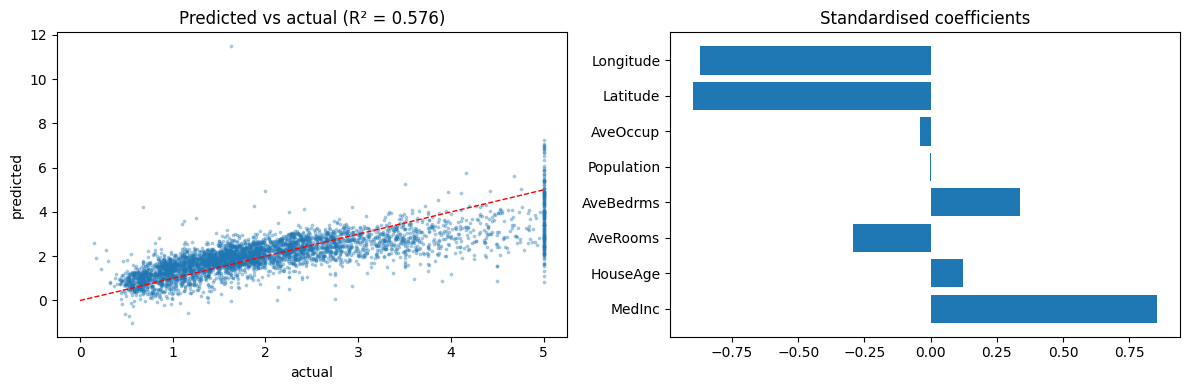

In [7]:
housing, online = load_online("California Housing", lambda: datasets.fetch_california_housing(return_X_y=True))

if online:
    Xh, yh = housing
    Xtr, Xte, ytr, yte = train_test_split(Xh, yh, test_size=0.2, random_state=SEED)
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)

    with timed("Ridge fit (16k rows)"):
        ridge = LinearRegression(alpha=1.0).fit(Xtr_s, ytr)
    with timed("SGD fit (16k rows)"):
        sgd = SGDRegression(learning_rate=0.01, n_iterations=200, batch_size=64, alpha=0.0).fit(Xtr_s, ytr)
    ref = linear_model.Ridge(alpha=1.0).fit(Xtr_s, ytr)

    r2 = {"ours Ridge": ridge.score(Xte_s, yte), "ours SGD": sgd.score(Xte_s, yte),
          "sklearn Ridge": ref.score(Xte_s, yte)}
    print({k: round(v, 4) for k, v in r2.items()})
    checks.at_least("California: Ridge test R²", r2["ours Ridge"], 0.55)
    checks.at_least("California: SGD test R²", r2["ours SGD"], 0.50)
    checks.at_most("California: |ours − sklearn| R²", abs(r2["ours Ridge"] - r2["sklearn Ridge"]), 1e-6)

    pred = ridge.predict(Xte_s)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(yte, pred, s=3, alpha=0.3)
    ax[0].plot([0, 5], [0, 5], "r--", lw=1)
    ax[0].set(title=f"Predicted vs actual (R² = {r2['ours Ridge']:.3f})", xlabel="actual", ylabel="predicted")
    ax[1].barh(datasets.fetch_california_housing().feature_names, ridge.coef_)
    ax[1].set(title="Standardised coefficients")
    plt.tight_layout(); plt.show()
else:
    checks.skip("California Housing checks", "dataset unavailable offline")

## 6. API contract and input validation

In [8]:
m = LinearRegression()
checks.check("fit() returns self", m.fit(X_dia, y_dia) is m)
checks.check("predict() returns one value per sample", m.predict(X_dia).shape == (len(X_dia),))

checks.raises("predict before fit raises", ValueError, lambda: LinearRegression().predict(X_dia))
checks.raises("SGD predict before fit raises", ValueError, lambda: SGDRegression().predict(X_dia))
checks.raises("NaN in X raises", ValueError, lambda: LinearRegression().fit(np.array([[1.0], [np.nan]]), [1, 2]))
checks.raises("inf in X raises", ValueError, lambda: check_array([[1.0], [np.inf]]))
checks.raises("None input raises", ValueError, lambda: check_array(None))
checks.raises("X / y length mismatch raises", ValueError, lambda: check_X_y(np.ones((5, 2)), np.ones(4)))
checks.raises("check_is_fitted on a fresh model raises", ValueError, lambda: check_is_fitted(LinearRegression()))
checks.check("1-D X is reshaped to a column", check_array(np.arange(5.0)).shape == (5, 1))

const_y = np.full(20, 3.0)
X_small = rng.normal(size=(20, 2))
checks.close("R² is 0.0 for a constant target", LinearRegression().fit(X_small, const_y).score(X_small, const_y), 0.0)

✅ fit() returns self
✅ predict() returns one value per sample
✅ predict before fit raises  (ValueError: This LinearRegression instance is not fitted yet.)
✅ SGD predict before fit raises  (ValueError: This SGDRegression instance is not fitted yet.)
✅ NaN in X raises  (ValueError: Input contains NaN or infinity.)
✅ inf in X raises  (ValueError: Input contains NaN or infinity.)
✅ None input raises  (ValueError: Input X cannot be None.)
✅ X / y length mismatch raises  (ValueError: Inconsistent numbers of samples: [5, 4])
✅ check_is_fitted on a fresh model raises  (ValueError: This LinearRegression instance is not fitted yet.)
✅ 1-D X is reshaped to a column
✅ R² is 0.0 for a constant target  (max |Δ| = 0.00e+00)


True

## Summary

In [9]:
checks.summary()

01 linear regression: 34 passed, 0 failed, 0 skipped, 2 known bug(s) (36 checks)

Known library bugs (not counted as failures):
  🐞 StandardScaler(with_mean=False) can transform: fit() leaves mean_=None, transform() then raises 'not fitted' | ValueError: This StandardScaler instance is not fitted yet.
  🐞 StandardScaler(with_std=False) can transform: fit() leaves std_=None, transform() then raises 'not fitted' | ValueError: This StandardScaler instance is not fitted yet.


,check,status,detail
0,OLS recovers the true coefficients,pass,max |Δ| = 2.31e-03
1,OLS recovers the true intercept,pass,max |Δ| = 2.32e-03
2,OLS R² on noise-free-ish data,pass,0.9998 ≥ 0.999
3,Ridge α=0.0: coef_ == sklearn,pass,max |Δ| = 1.77e-11
4,Ridge α=0.0: intercept_ == sklearn,pass,max |Δ| = 2.84e-14
5,Ridge α=0.1: coef_ == sklearn,pass,max |Δ| = 3.69e-12
6,Ridge α=0.1: intercept_ == sklearn,pass,max |Δ| = 8.53e-14
7,Ridge α=1.0: coef_ == sklearn,pass,max |Δ| = 5.68e-13
8,Ridge α=1.0: intercept_ == sklearn,pass,max |Δ| = 5.68e-14
9,Ridge α=10.0: coef_ == sklearn,pass,max |Δ| = 9.95e-14
